In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sympy import init_printing
import sympy as sym
from scipy.integrate import solve_ivp
import networkx as nx
from scipy.interpolate import interp1d

In [10]:
def vp(t,x):
    xx,v = x
    xdot = v
    vdot = mu*(1-xx*xx)*v - xx
    return (xdot,vdot)


def solve_vdp_with_delay(mu, x0, tspan, dt, T):
    t_eval = np.arange(tspan[0],tspan[1],dt)
    sol = solve_ivp(vp, tspan, x0, t_eval=t_eval)
    x = sol.y[0]
    f = interp1d(t_eval, x, bounds_error=False, fill_value=np.nan)
    x_delay  = f(t_eval - T)
    x_delay2 = f(t_eval - 2*T)

    return t_eval, x, x_delay, x_delay2

def plot_delay_embedding_3d(t, x, xT, x2T, T):
    # mask out NaNs (early times where delays are undefined)
    mask = ~(np.isnan(xT) | np.isnan(x2T))

    fig = plt.figure(figsize=(7,6),dpi = 300)
    ax = fig.add_subplot(111, projection='3d')

    ax.plot(
        x[mask], 
        xT[mask], 
        x2T[mask], 
        linewidth=1.5
    )
    ax.set_xlabel("x(t)")
    ax.set_ylabel(f"x(t - {T})")
    ax.set_zlabel(f"x(t - {2*T})")

    ax.set_title("3D Delay Embedding of Van der Pol Oscillator")

    plt.tight_layout()

def plot_delay_embeddings_3d_multiT(t, x, xT_list, x2T_list, T_list):

    fig = plt.figure(figsize=(8,7),dpi=300)
    ax = fig.add_subplot(111, projection='3d')
    for xT, x2T, T in zip(xT_list, x2T_list, T_list):
        mask = ~(np.isnan(xT) | np.isnan(x2T))
        ax.plot(
            x[mask],
            xT[mask],
            x2T[mask],
            linewidth=1.7,
            label=f"T = {T}"
        )
    ax.set_xlabel("x(t)")
    ax.set_ylabel("x(t - T)")
    ax.set_zlabel("x(t - 2T)")
    ax.set_title("Embeddings")
    ax.legend()
    plt.tight_layout()
    plt.show()



Text(0, 0.5, 'x')

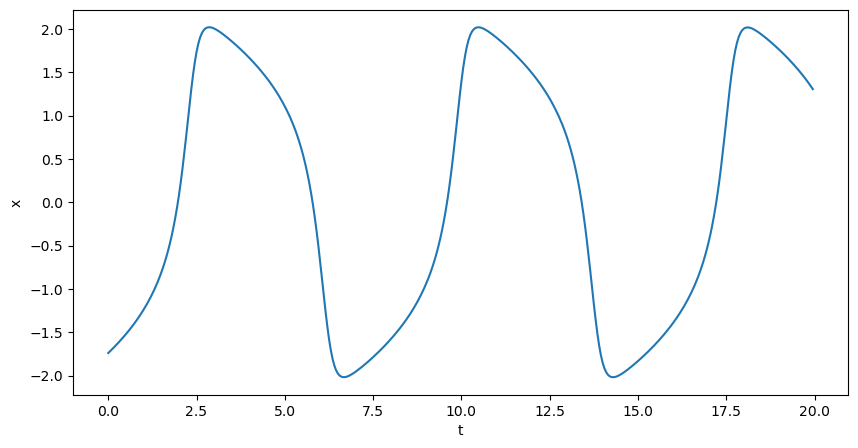

In [11]:
mu = 2
tspan = (0,20)
dt = 0.05
t_eval = np.arange(tspan[0],tspan[1],dt)
x0= np.array([-1.7400873890778068,0.39367773558017666])
sol = solve_ivp(vp, tspan, x0, t_eval=t_eval)

plt.figure(figsize = (10,5))
plt.plot(t_eval,sol.y[0])
plt.xlabel("t")
plt.ylabel("x")

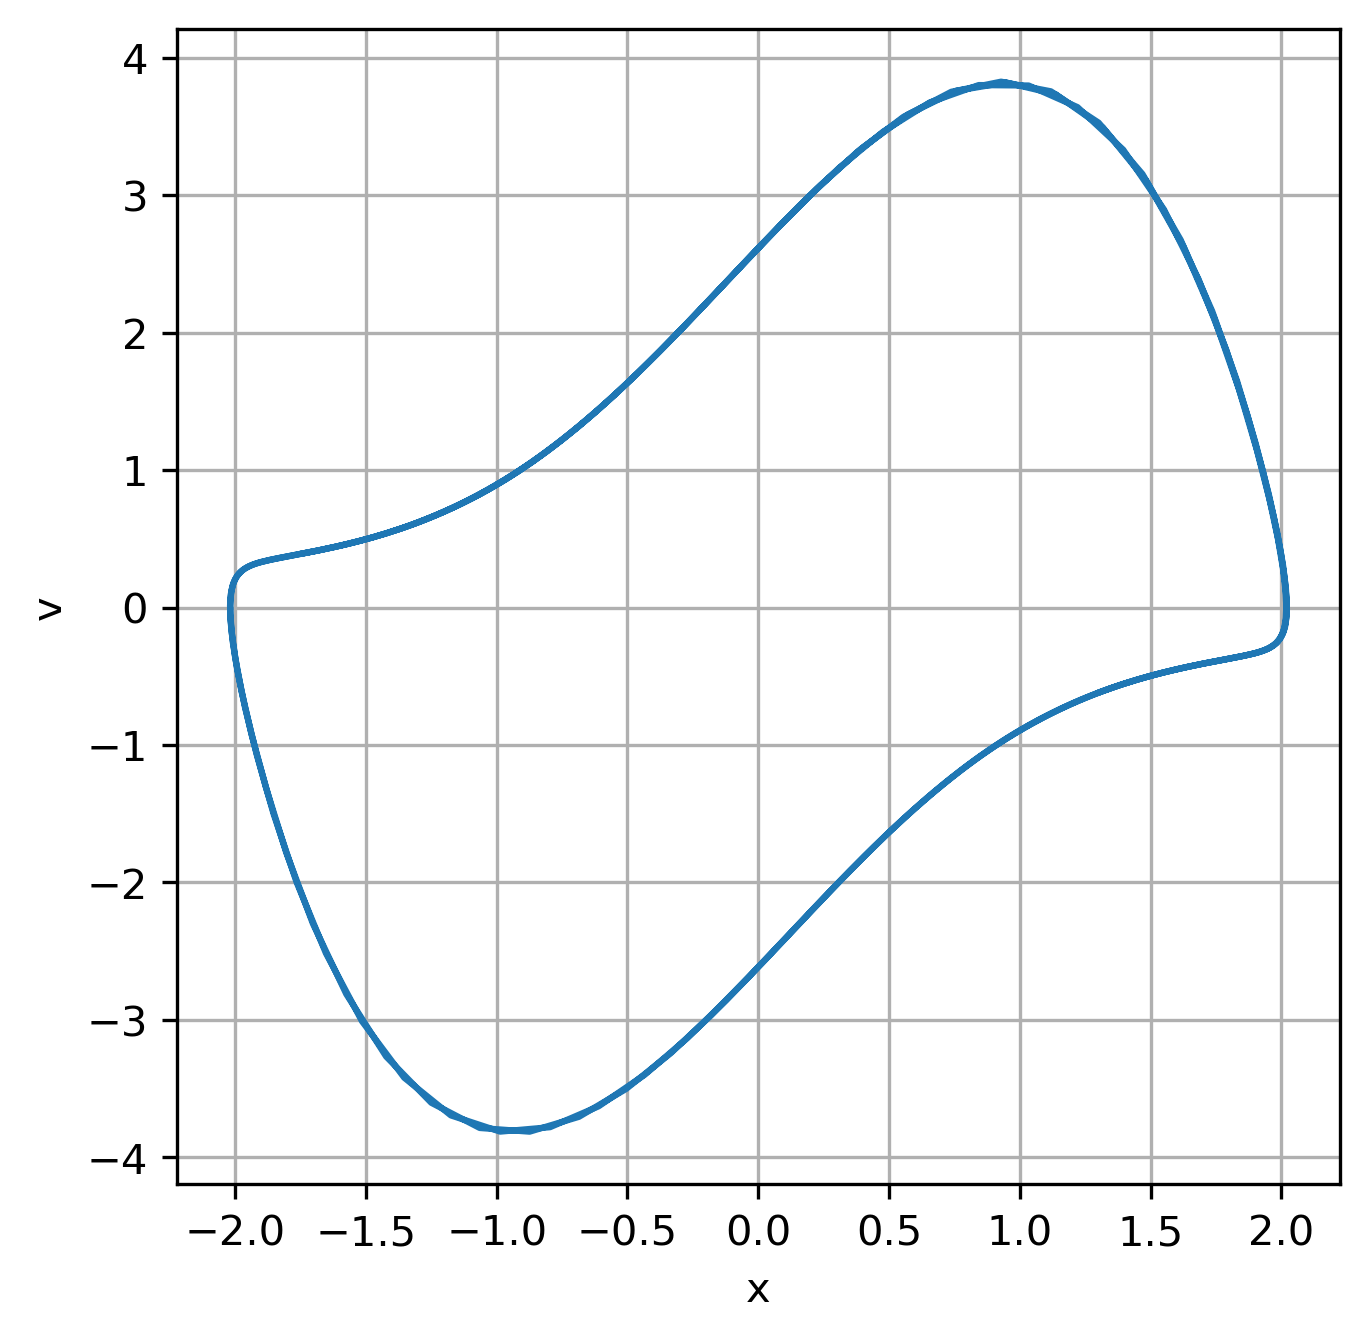

In [12]:
plt.figure(figsize = (5,5),dpi=300)
plt.plot(sol.y[0],sol.y[1])
plt.xlabel("x")
plt.ylabel("v")
plt.grid()

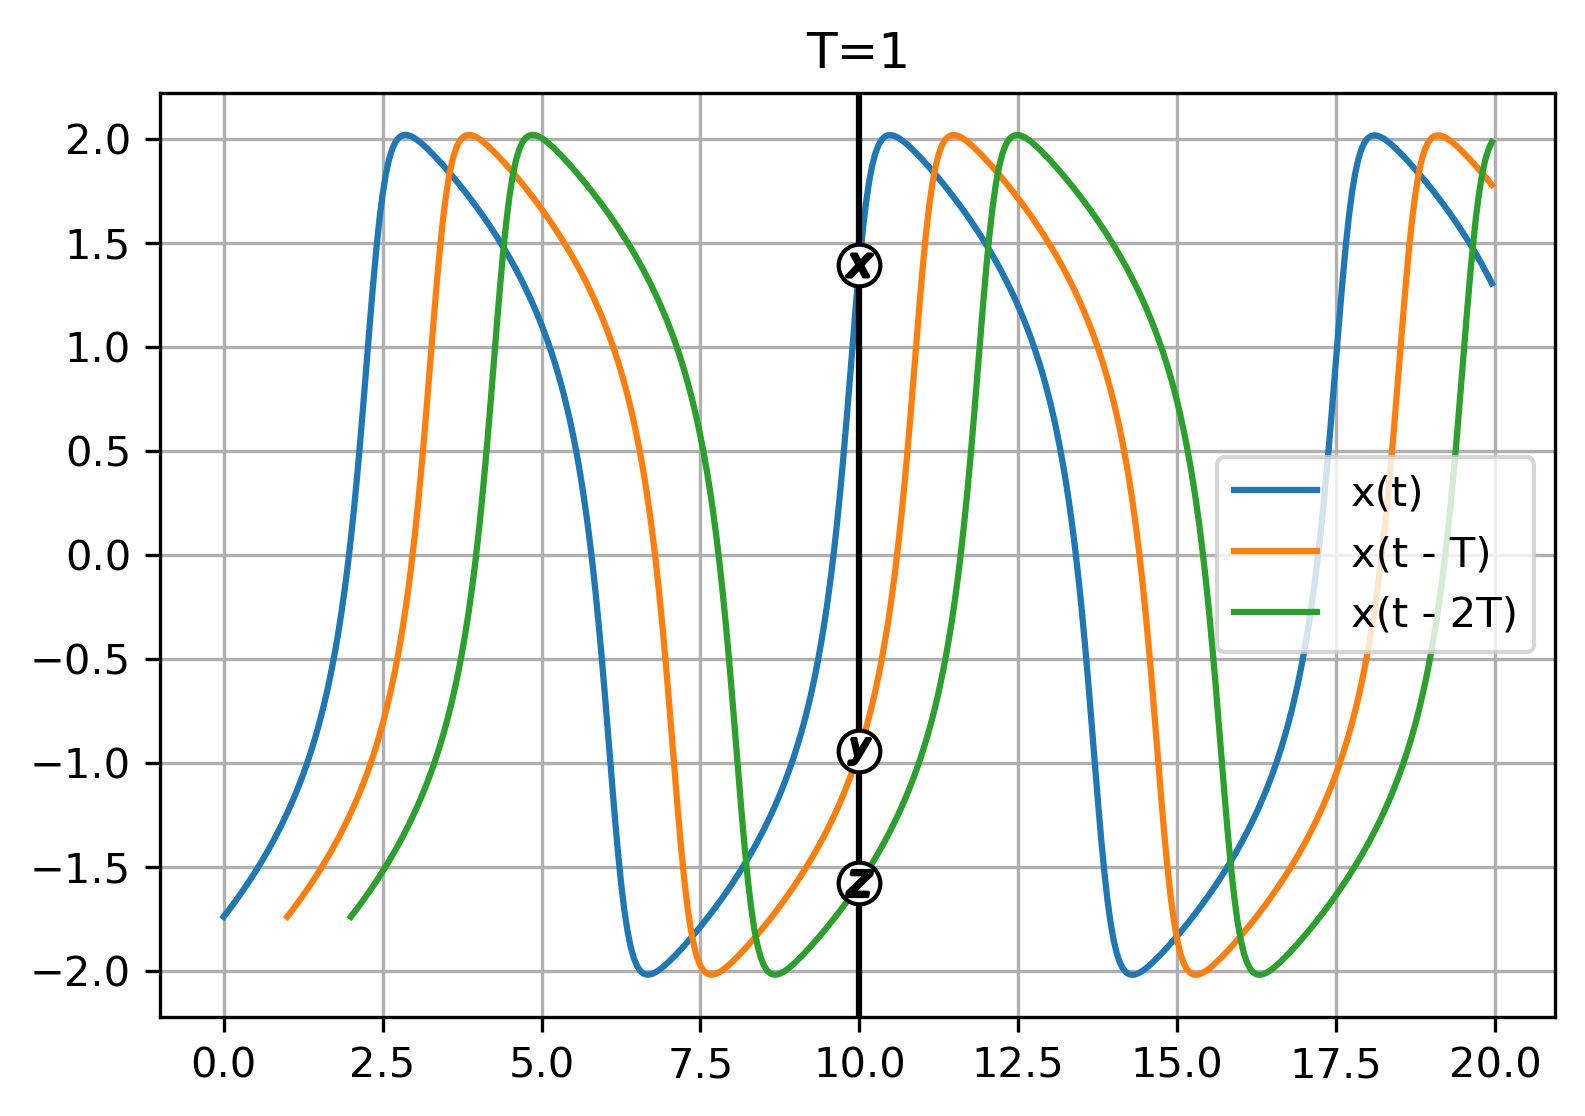

In [13]:
T = 1
t, x, xT, x2T = solve_vdp_with_delay(mu, x0, tspan, dt, T)

plt.figure(figsize=(6,4),dpi=300)
plt.title("T=1")
plt.plot(t, x, label="x(t)")
plt.plot(t, xT, label="x(t - T)")
plt.plot(t, x2T, label="x(t - 2T)")
plt.axvline(10,c="black")
plt.scatter(t[200],x[200],zorder=3,marker = r"$x$",edgecolor = "black")
plt.scatter(t[200],xT[200],zorder=3,marker = r"$y$",edgecolor = "black")
plt.scatter(t[200],x2T[200],zorder=3,marker = r"$z$",edgecolor = "black")
plt.scatter(t[200],x2T[200],zorder=2,marker = "o",edgecolor = "black",s = 100,facecolor = "white")
plt.scatter(t[200],xT[200],zorder=2,marker = "o",edgecolor = "black",s = 100,facecolor = "white")
plt.scatter(t[200],x[200],zorder=2,marker = "o",edgecolor = "black",s = 100,facecolor = "white")

plt.legend()
plt.grid()
plt.show()


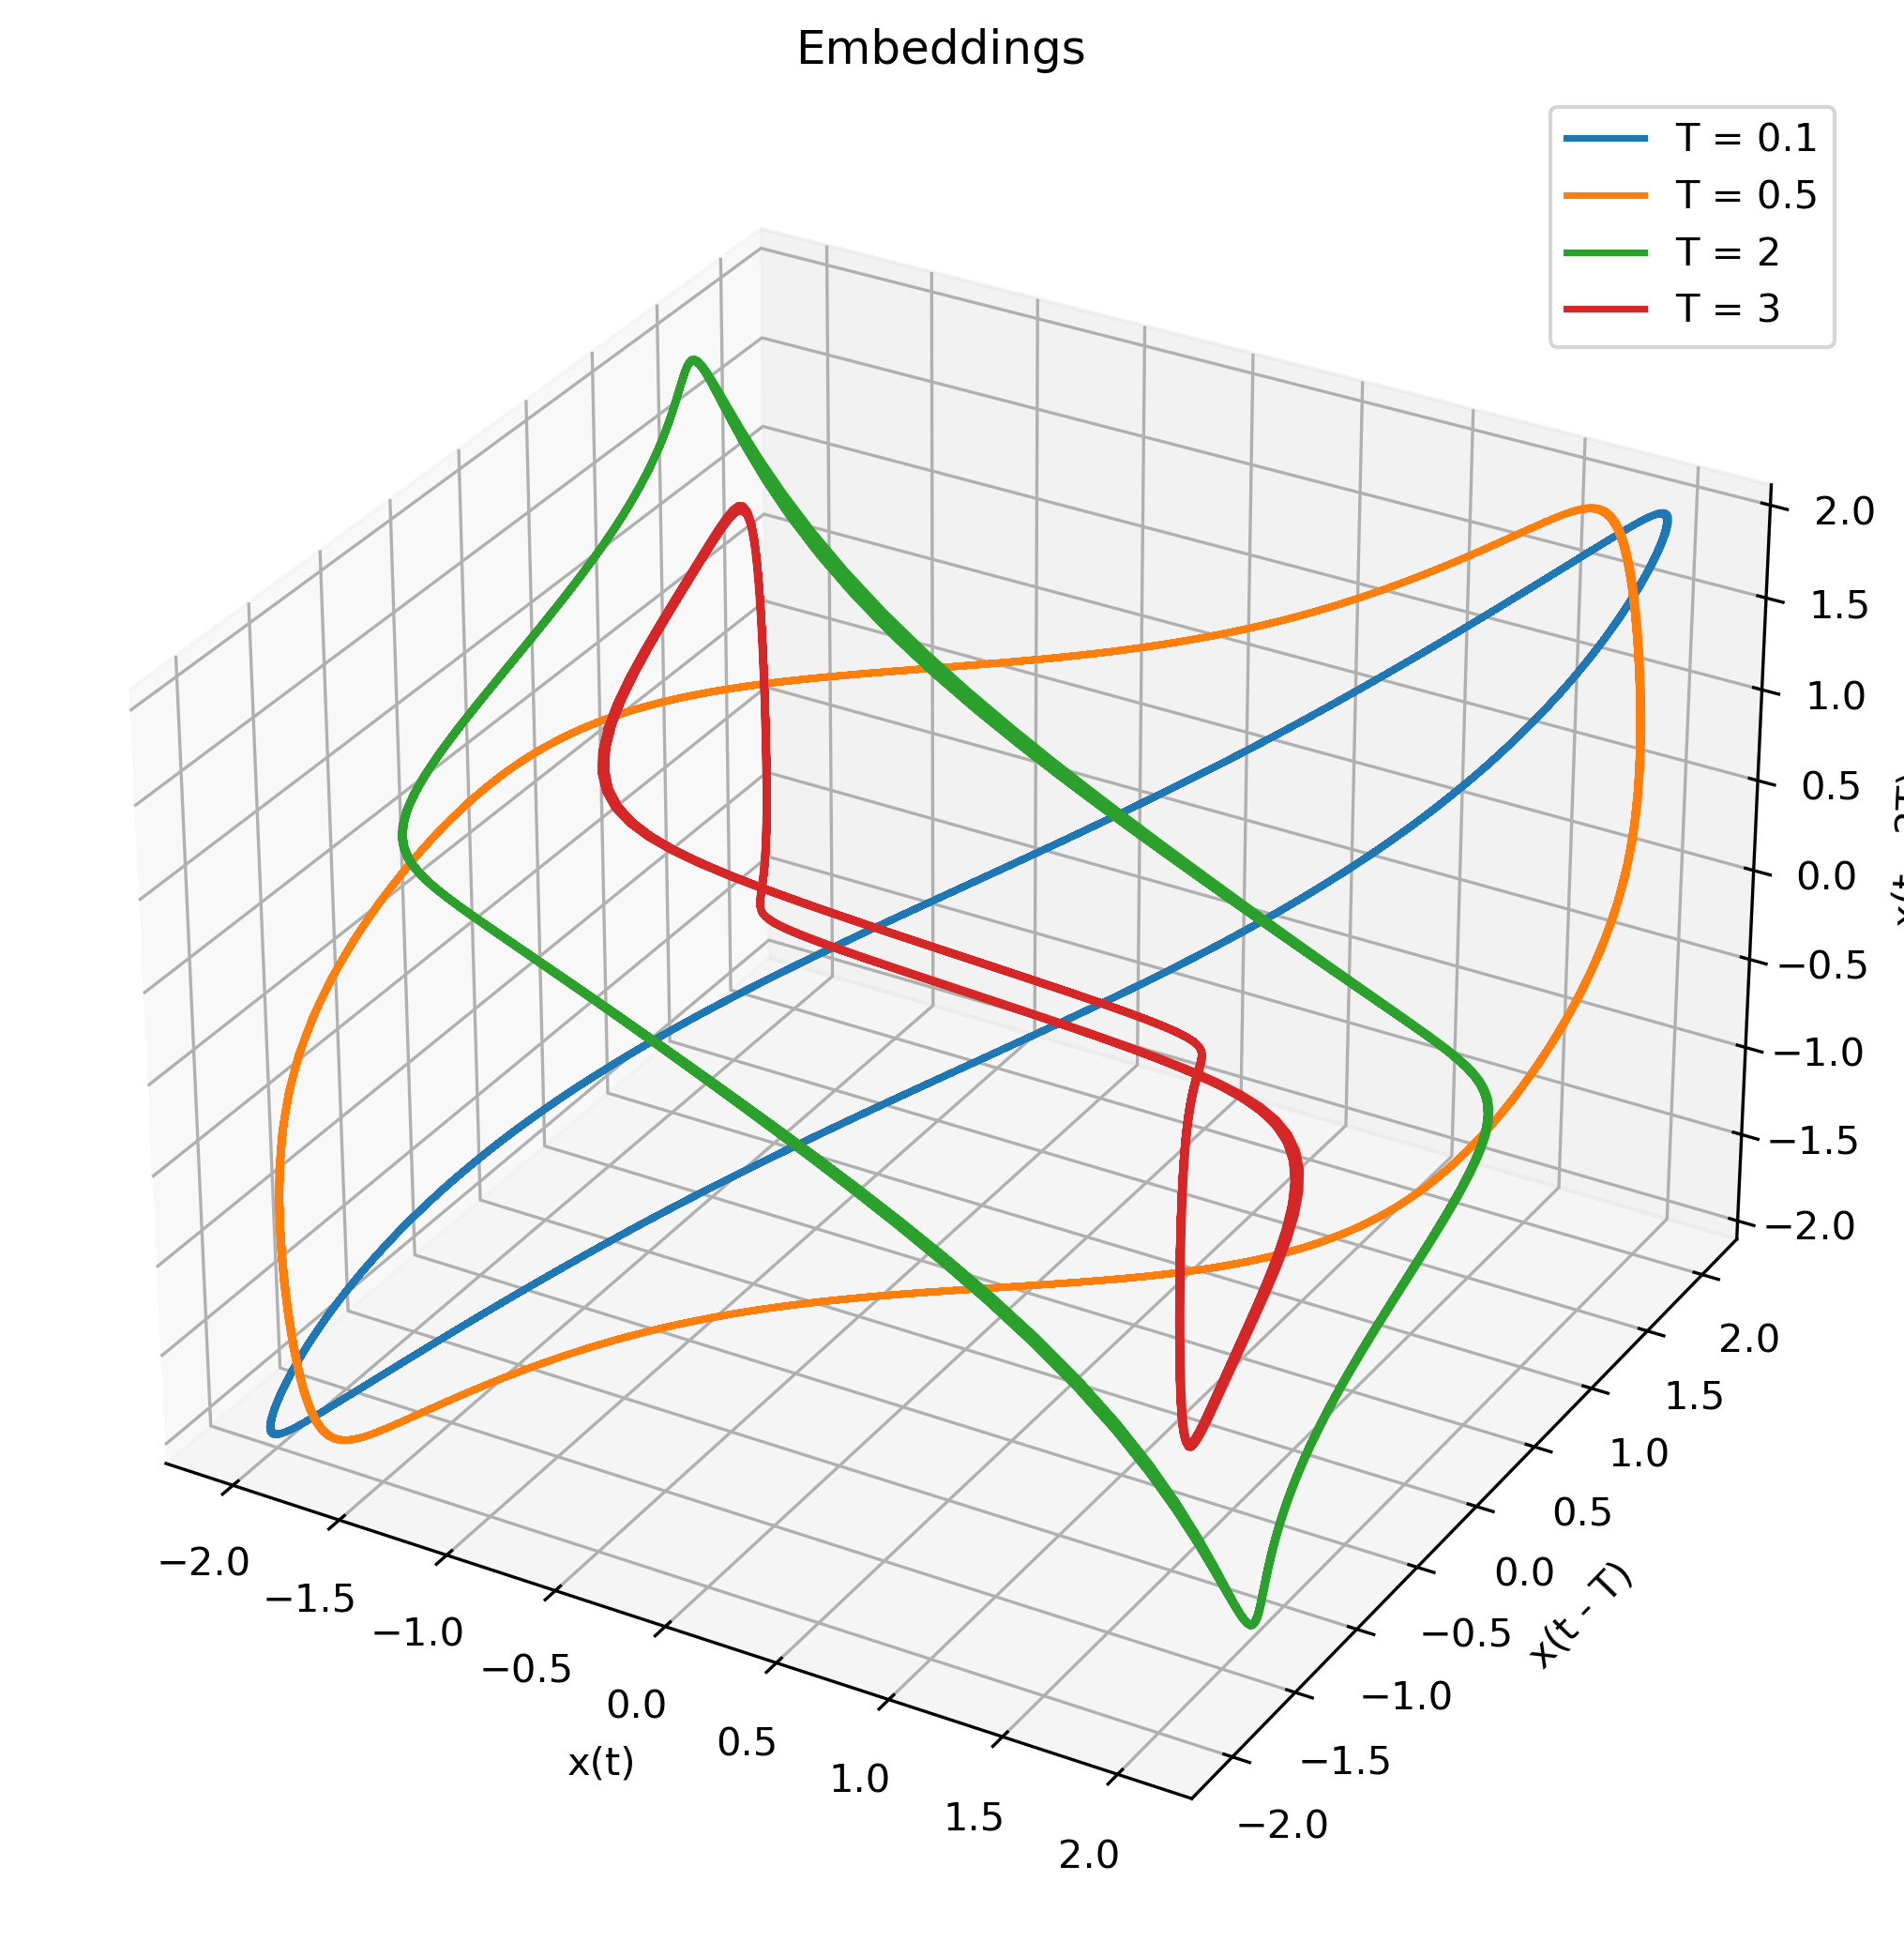

<Figure size 640x480 with 0 Axes>

In [17]:
T_list = [0.1, 0.5,2,3]
xT_list = []
x2T_list = []

for T in T_list:
    _, _, xT, x2T = solve_vdp_with_delay(mu, x0, tspan, dt, T)
    xT_list.append(xT)
    x2T_list.append(x2T)

plot_delay_embeddings_3d_multiT(t, x, xT_list, x2T_list, T_list)
plt.tight_layout()


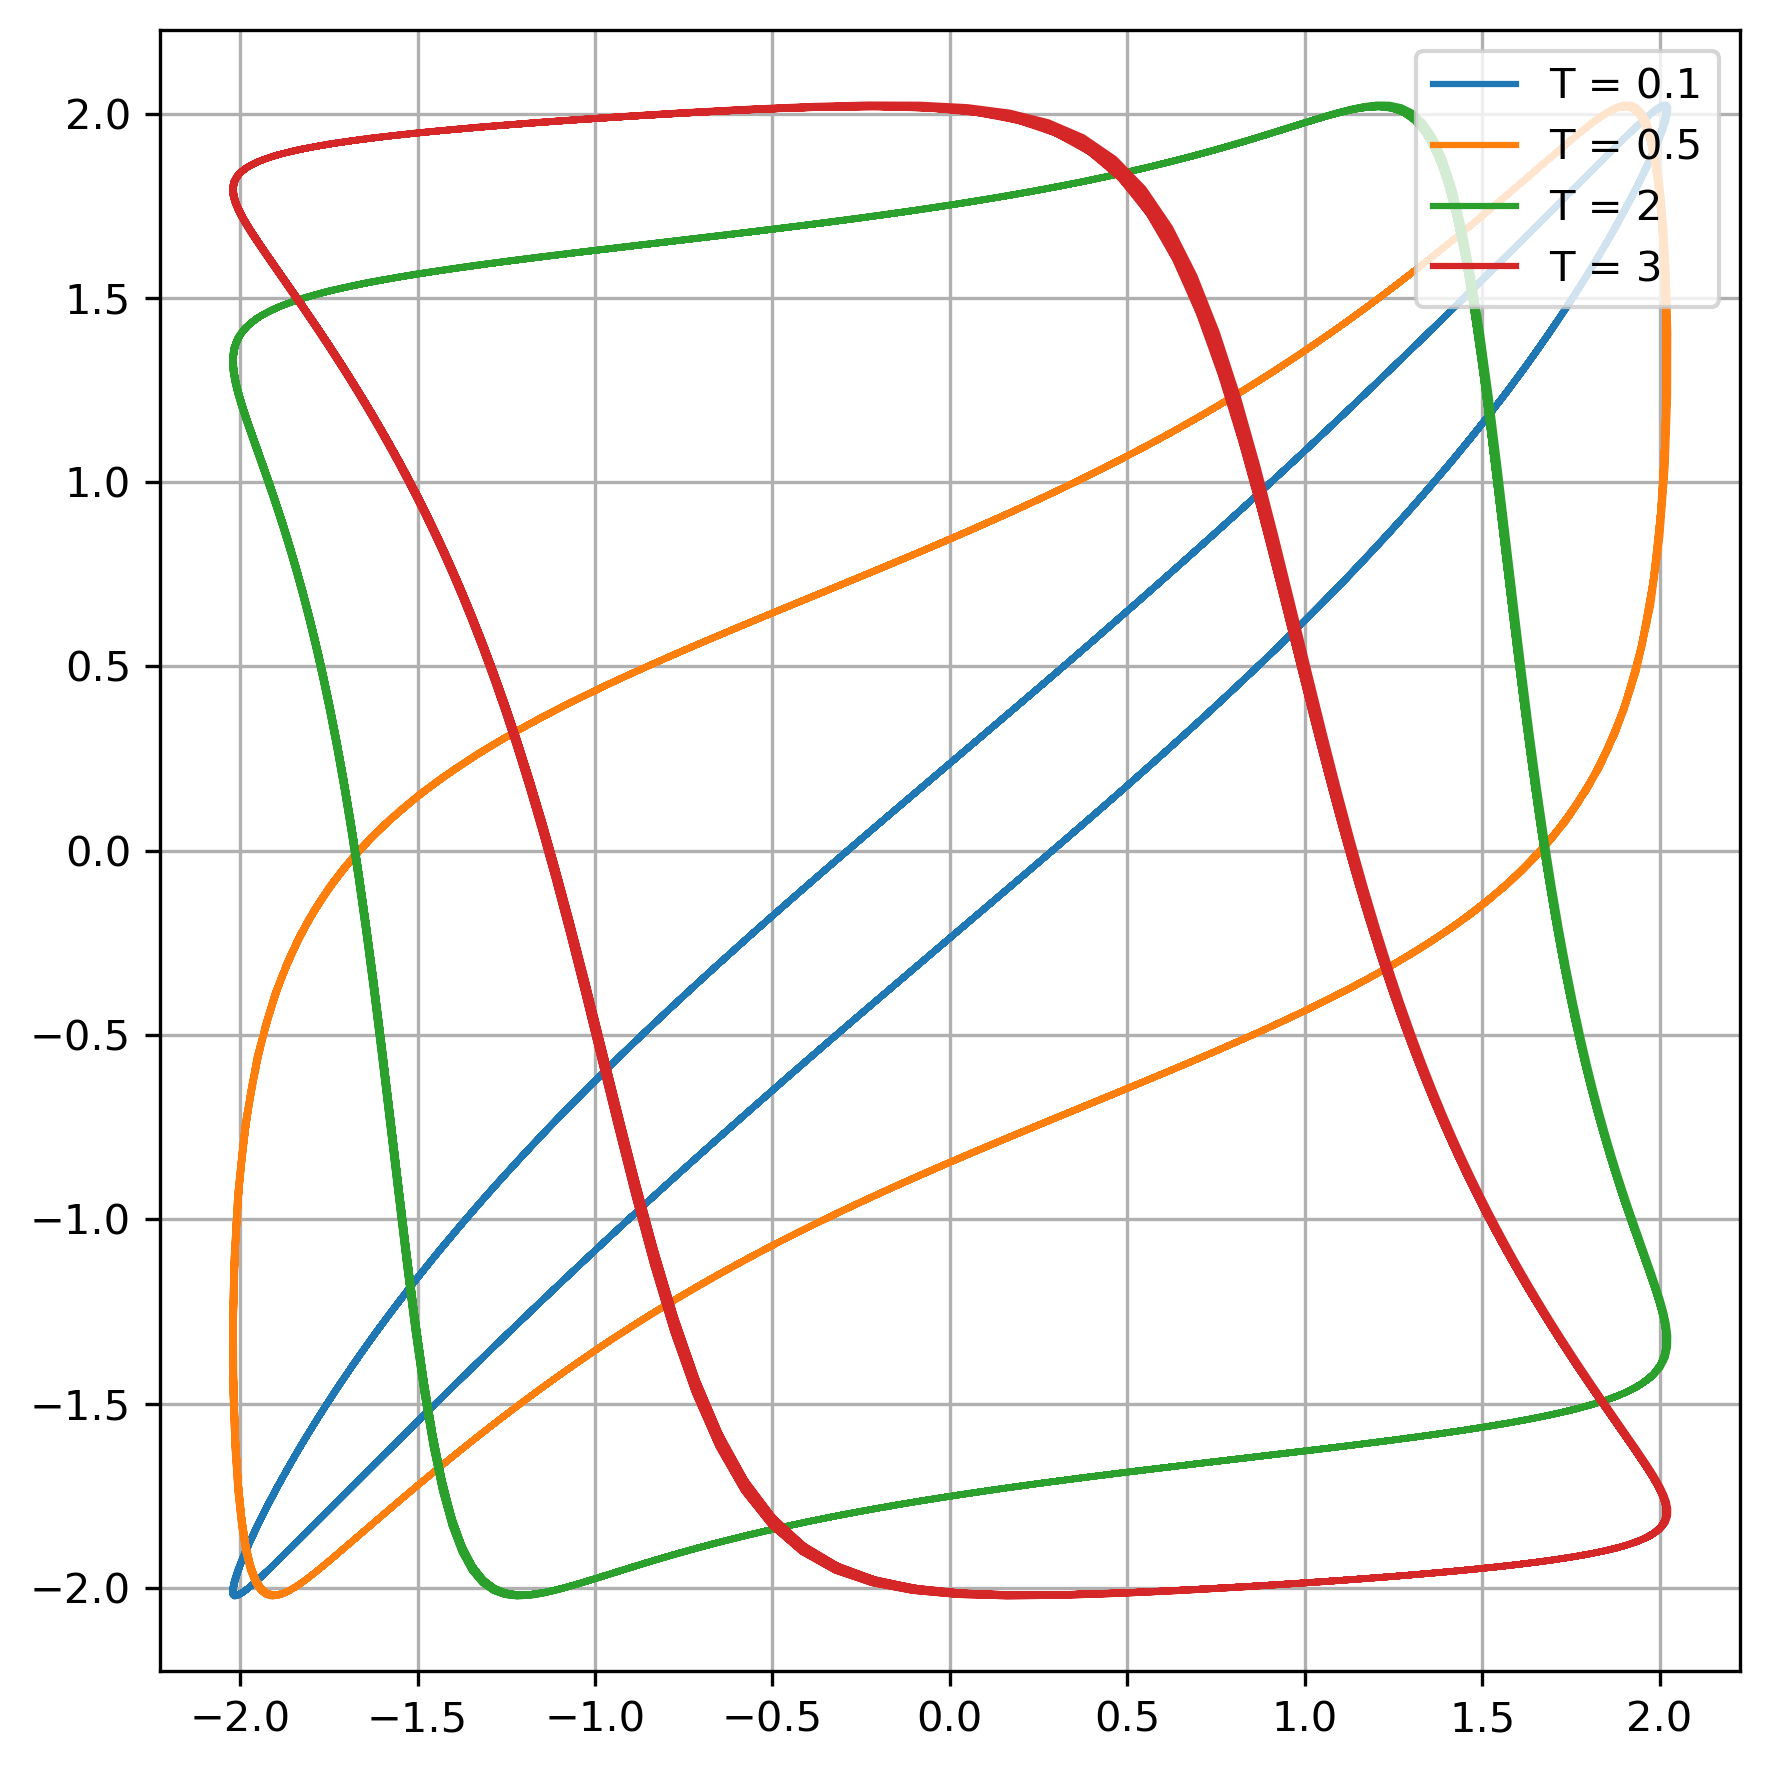

In [26]:
fig, ax = plt.subplots(figsize = (6,6),dpi = 300)

ax.plot(x,xT_list[0],label = "T = 0.1")
ax.plot(x,xT_list[1],label = "T = 0.5")
ax.plot(x,xT_list[2],label = "T = 2")
ax.plot(x,xT_list[3],label = "T = 3")

ax.legend(loc = "upper right")
ax.grid()
plt.tight_layout()


In [15]:
mi =np.argmin(x)
ma = np.argmax(x)
p = t_eval[mi]- t_eval[ma]


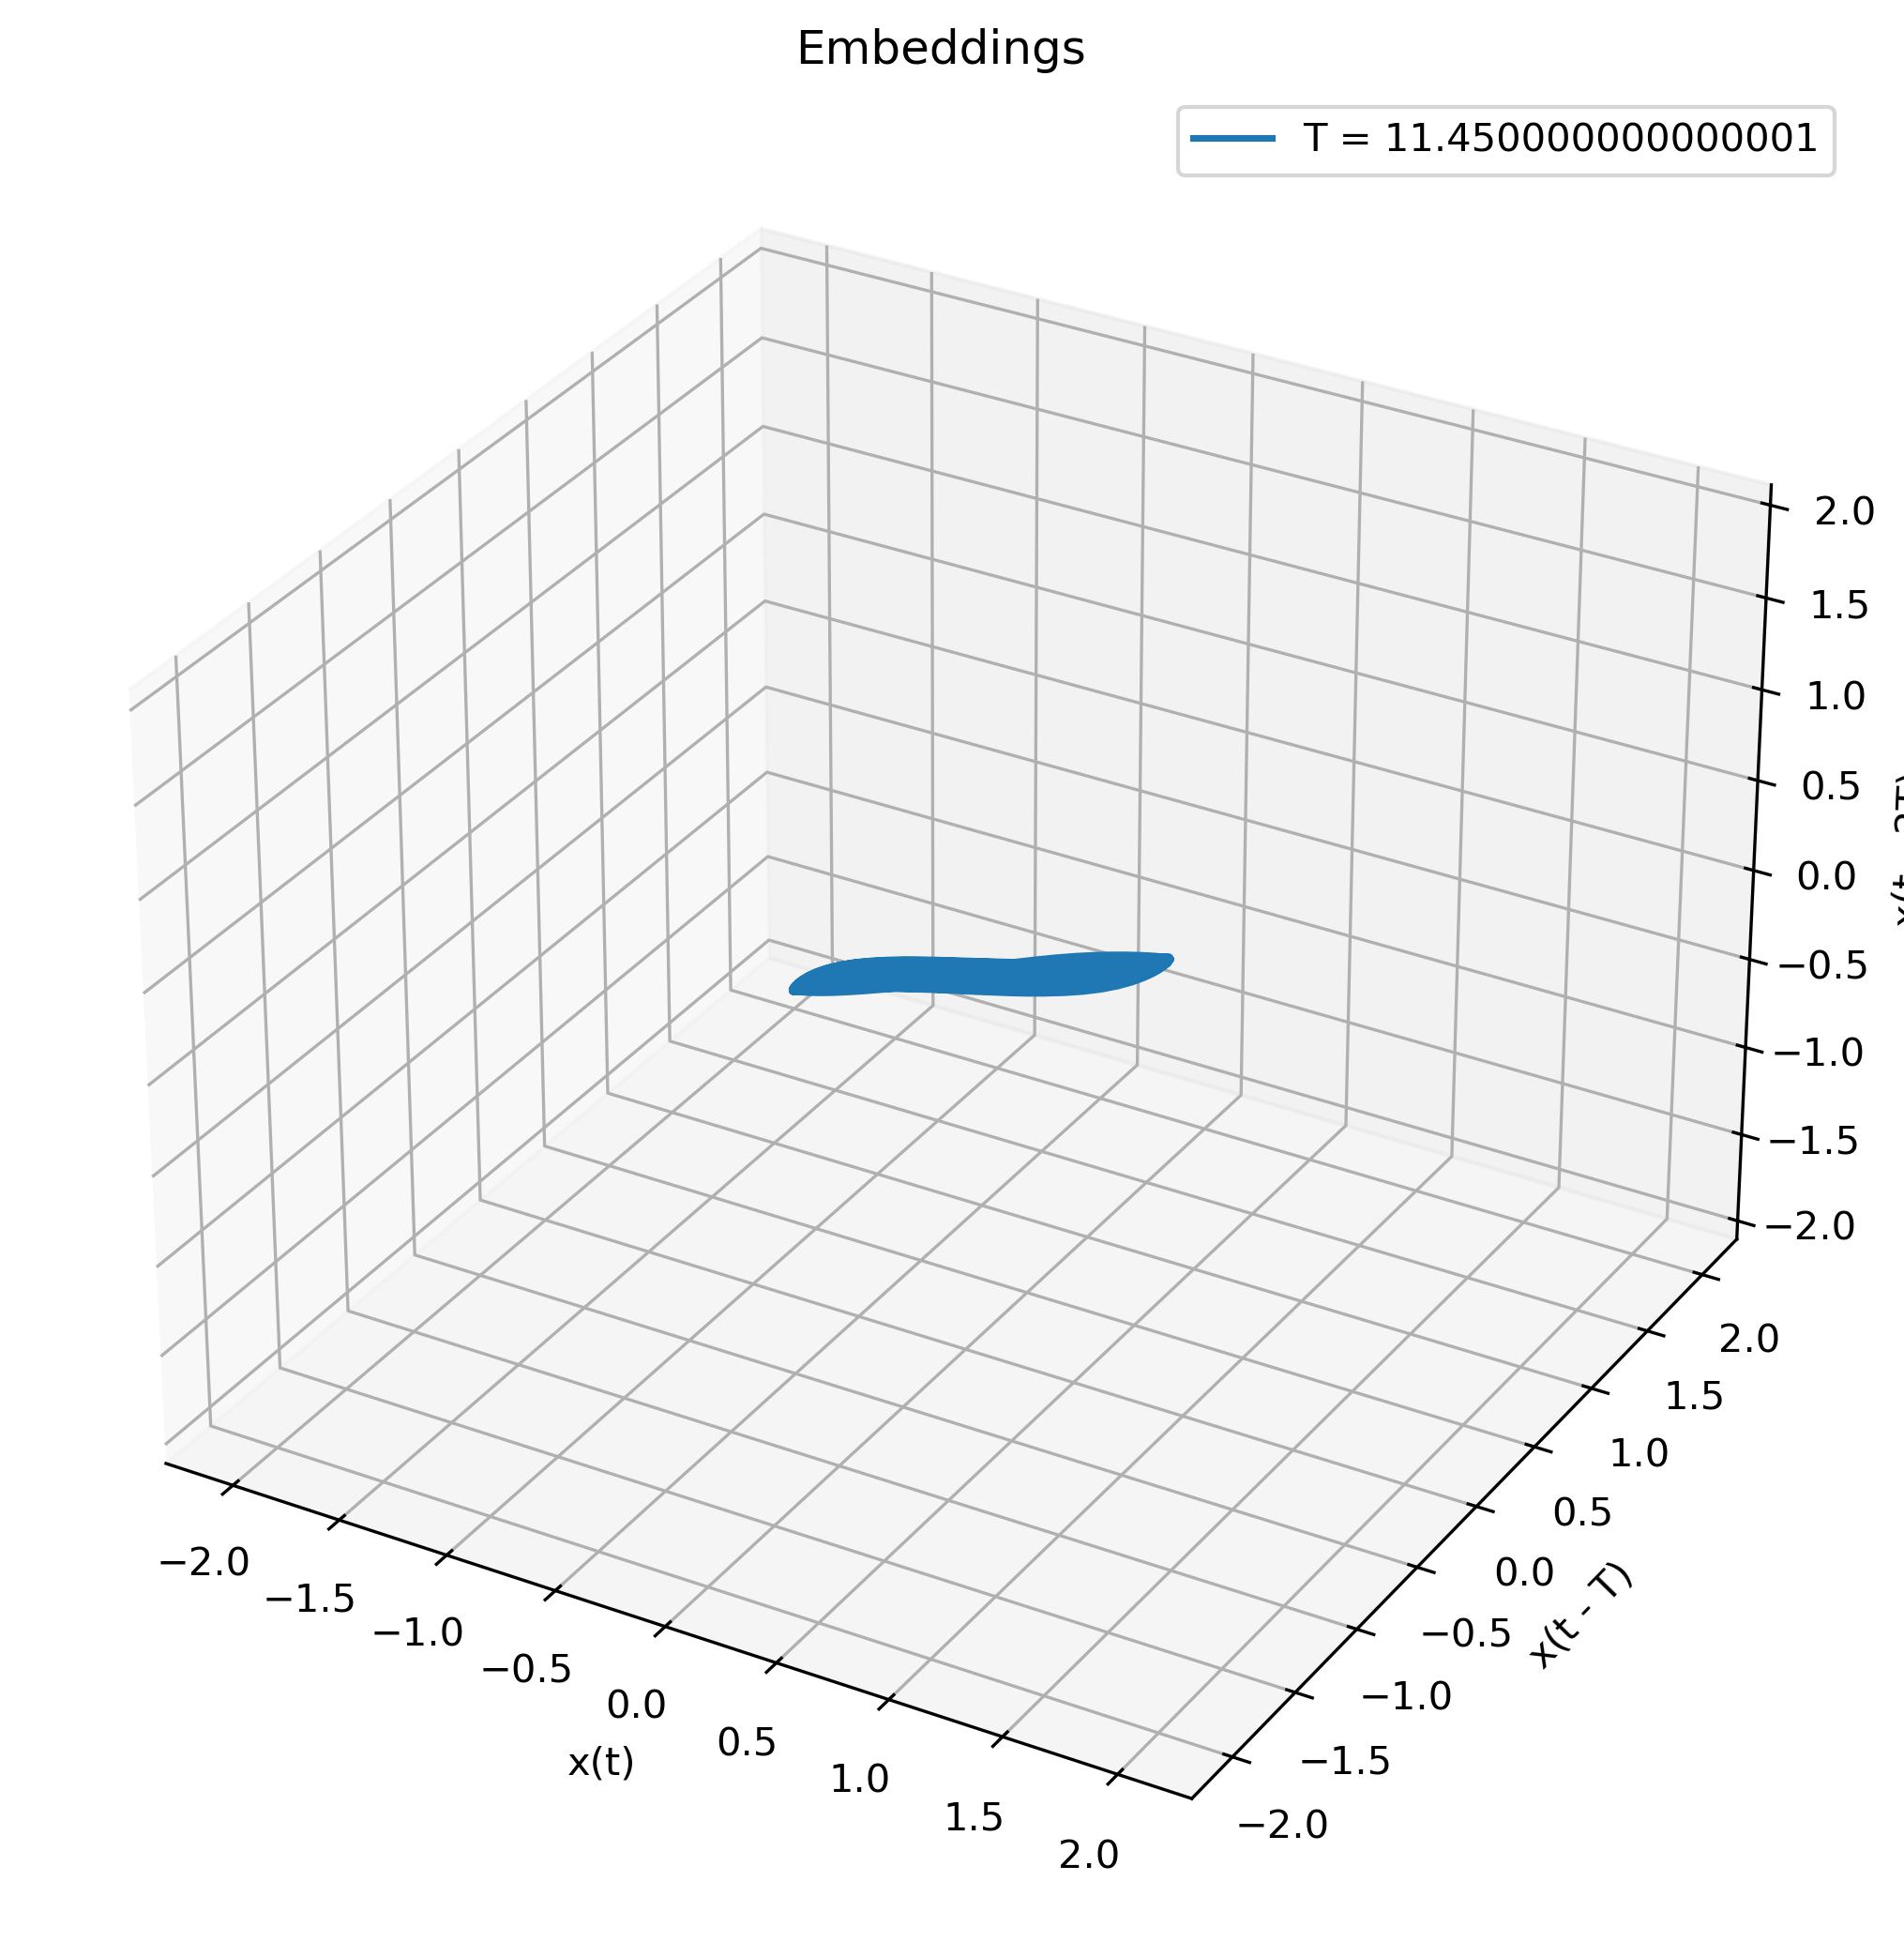

In [16]:
mu = 2
tspan = (0,200)
dt = 0.05
t_eval = np.arange(tspan[0],tspan[1],dt)
x0= np.array([-1.7400873890778068,0.39367773558017666])
sol = solve_ivp(vp, tspan, x0, t_eval=t_eval)
t = sol.t
x = sol.y[0]

T_list = [p]
xT_list = []
x2T_list = []

for T in T_list:
    _, _, xT, x2T = solve_vdp_with_delay(mu, x0, tspan, dt, T)
    xT_list.append(xT)
    x2T_list.append(x2T)

plot_delay_embeddings_3d_multiT(t, x, xT_list, x2T_list, T_list)